# Task 13

# Direct Preference Optimization (DPO)

## Objective

Align a language model with human preferences using pairwise preference optimization.

---

In [1]:
# Install Required Libraries

!pip -q install transformers

!pip -q install datasets

!pip -q install accelerate

!pip -q install trl

!pip -q install matplotlib

!pip -q install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 889.0/889.0 kB 55.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 44.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 19.2 MB/s eta 0:00:00


In [2]:
# Imports

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from transformers import AutoTokenizer
from transformers import AutoModelForCausalLM

In [3]:
# Device

device = torch.device(

    "cuda"

    if torch.cuda.is_available()

    else "cpu"

)

print("Device :",device)

Device : cuda


In [4]:
# Load Models

MODEL_NAME = "gpt2"

tokenizer = AutoTokenizer.from_pretrained(

    MODEL_NAME

)

tokenizer.pad_token = tokenizer.eos_token

policy_model = AutoModelForCausalLM.from_pretrained(

    MODEL_NAME

).to(device)

reference_model = AutoModelForCausalLM.from_pretrained(

    MODEL_NAME

).to(device)

reference_model.eval()

for param in reference_model.parameters():

    param.requires_grad = False

print("Policy Model Loaded")

print("Reference Model Loaded (Frozen)")

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Policy Model Loaded
Reference Model Loaded (Frozen)


In [5]:
# Preference Dataset

preference_data = [

    {
        "prompt":"What is Artificial Intelligence?",

        "chosen":"Artificial Intelligence is the simulation of human intelligence using computer systems.",

        "rejected":"AI is just computers."
    },

    {
        "prompt":"Explain Python.",

        "chosen":"Python is a high-level programming language widely used for AI, web development and automation.",

        "rejected":"Python is a snake."
    },

    {
        "prompt":"What is Machine Learning?",

        "chosen":"Machine Learning enables computers to learn patterns from data without explicit programming.",

        "rejected":"Machine Learning means machines."
    },

    {
        "prompt":"Define Cloud Computing.",

        "chosen":"Cloud Computing delivers computing resources over the internet on demand.",

        "rejected":"Clouds are in the sky."
    },

    {
        "prompt":"What is Deep Learning?",

        "chosen":"Deep Learning is a subset of Machine Learning based on multi-layer neural networks.",

        "rejected":"Deep Learning is studying deeply."
    },

    {
        "prompt":"Explain Data Science.",

        "chosen":"Data Science combines statistics, machine learning and programming to extract insights from data.",

        "rejected":"It is about data."
    },

    {
        "prompt":"What is NLP?",

        "chosen":"Natural Language Processing enables computers to understand and generate human language.",

        "rejected":"NLP means language."
    },

    {
        "prompt":"Explain Neural Networks.",

        "chosen":"Neural Networks are computational models inspired by biological neurons.",

        "rejected":"Neural networks are networks."
    }

]

df = pd.DataFrame(preference_data)

df.head()

,prompt,chosen,rejected
0,What is Artificial Intelligence?,Artificial Intelligence is the simulation of h...,AI is just computers.
1,Explain Python.,Python is a high-level programming language wi...,Python is a snake.
2,What is Machine Learning?,Machine Learning enables computers to learn pa...,Machine Learning means machines.
3,Define Cloud Computing.,Cloud Computing delivers computing resources o...,Clouds are in the sky.
4,What is Deep Learning?,Deep Learning is a subset of Machine Learning ...,Deep Learning is studying deeply.


In [6]:
# Dataset Summary

print("="*60)

print("PREFERENCE DATASET")

print("="*60)

print()

print("Total Samples :",len(df))

print()

print(df.head())

PREFERENCE DATASET

Total Samples : 8

                             prompt  \
0  What is Artificial Intelligence?   
1                   Explain Python.   
2         What is Machine Learning?   
3           Define Cloud Computing.   
4            What is Deep Learning?   

                                              chosen  \
0  Artificial Intelligence is the simulation of h...   
1  Python is a high-level programming language wi...   
2  Machine Learning enables computers to learn pa...   
3  Cloud Computing delivers computing resources o...   
4  Deep Learning is a subset of Machine Learning ...   

                            rejected  
0              AI is just computers.  
1                 Python is a snake.  
2   Machine Learning means machines.  
3             Clouds are in the sky.  
4  Deep Learning is studying deeply.  


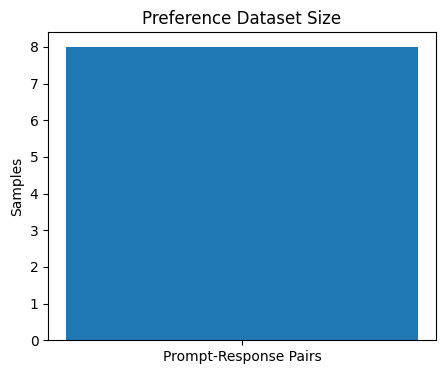

In [7]:
# Dataset Visualization

plt.figure(figsize=(5,4))

plt.bar(

    ["Prompt-Response Pairs"],

    [len(df)]

)

plt.title("Preference Dataset Size")

plt.ylabel("Samples")

plt.show()

In [8]:
# Example Pair

sample = df.iloc[0]

print("="*60)

print("PROMPT")

print("="*60)

print(sample["prompt"])

print()

print("="*60)

print("CHOSEN")

print("="*60)

print(sample["chosen"])

print()

print("="*60)

print("REJECTED")

print("="*60)

print(sample["rejected"])

PROMPT
What is Artificial Intelligence?

CHOSEN
Artificial Intelligence is the simulation of human intelligence using computer systems.

REJECTED
AI is just computers.


In [9]:
# HuggingFace Dataset

from datasets import Dataset

dataset = Dataset.from_pandas(df)

print(dataset)

print()

print(dataset[0])

Dataset({
    features: ['prompt', 'chosen', 'rejected'],
    num_rows: 8
})

{'prompt': 'What is Artificial Intelligence?', 'chosen': 'Artificial Intelligence is the simulation of human intelligence using computer systems.', 'rejected': 'AI is just computers.'}


In [10]:
# Tokenization

MAX_LENGTH = 128

def tokenize_pair(prompt, response):

    text = prompt + "\n\nAssistant: " + response

    encoding = tokenizer(
        text,
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH,
        return_tensors="pt"
    )

    return {
        "input_ids": encoding["input_ids"].to(device),
        "attention_mask": encoding["attention_mask"].to(device)
    }

print("Tokenization Function Ready")

Tokenization Function Ready


In [11]:
# Sequence Log Probability

def sequence_log_probability(model, input_ids, attention_mask):

    outputs = model(
        input_ids=input_ids,
        attention_mask=attention_mask
    )

    logits = outputs.logits

    shift_logits = logits[:, :-1, :]

    shift_labels = input_ids[:, 1:]

    log_probs = F.log_softmax(
        shift_logits,
        dim=-1
    )

    token_log_probs = log_probs.gather(
        dim=-1,
        index=shift_labels.unsqueeze(-1)
    ).squeeze(-1)

    sequence_score = token_log_probs.sum(dim=1)

    return sequence_score

In [12]:
# Policy Log Probabilities

sample = dataset[0]

chosen = tokenize_pair(
    sample["prompt"],
    sample["chosen"]
)

rejected = tokenize_pair(
    sample["prompt"],
    sample["rejected"]
)

policy_chosen = sequence_log_probability(

    policy_model,

    chosen["input_ids"],

    chosen["attention_mask"]

)

policy_rejected = sequence_log_probability(

    policy_model,

    rejected["input_ids"],

    rejected["attention_mask"]

)

print("Policy Chosen :", policy_chosen.item())

print("Policy Rejected :", policy_rejected.item())

Policy Chosen : -1306.93017578125
Policy Rejected : -1438.706298828125


In [13]:
# Reference Log Probabilities

with torch.no_grad():

    ref_chosen = sequence_log_probability(

        reference_model,

        chosen["input_ids"],

        chosen["attention_mask"]

    )

    ref_rejected = sequence_log_probability(

        reference_model,

        rejected["input_ids"],

        rejected["attention_mask"]

    )

print("Reference Chosen :", ref_chosen.item())

print("Reference Rejected :", ref_rejected.item())

Reference Chosen : -1306.93017578125
Reference Rejected : -1438.706298828125


In [14]:
# Relative Log-Likelihood

policy_margin = policy_chosen - policy_rejected

reference_margin = ref_chosen - ref_rejected

relative_margin = policy_margin - reference_margin

print("="*60)

print("Policy Margin      :", round(policy_margin.item(),4))

print("Reference Margin   :", round(reference_margin.item(),4))

print("Relative Margin    :", round(relative_margin.item(),4))

Policy Margin      : 131.7761
Reference Margin   : 131.7761
Relative Margin    : 0.0


In [15]:
# Direct Preference Optimization Loss

BETA = 0.1

def dpo_loss(

    policy_chosen,

    policy_rejected,

    reference_chosen,

    reference_rejected

):

    policy_margin = policy_chosen - policy_rejected

    reference_margin = reference_chosen - reference_rejected

    logits = BETA * (

        policy_margin

        -

        reference_margin

    )

    loss = -F.logsigmoid(logits)

    return loss.mean()

In [16]:
# Optimizer

optimizer = torch.optim.AdamW(

    policy_model.parameters(),

    lr=5e-6

)

print("Optimizer Initialized")

Optimizer Initialized


In [17]:
# DPO Training

EPOCHS = 3

loss_history = []

policy_model.train()

for epoch in range(EPOCHS):

    running_loss = 0

    for sample in dataset:

        chosen = tokenize_pair(

            sample["prompt"],

            sample["chosen"]

        )

        rejected = tokenize_pair(

            sample["prompt"],

            sample["rejected"]

        )

        # -------------------------
        # Policy Scores
        # -------------------------

        policy_chosen = sequence_log_probability(

            policy_model,

            chosen["input_ids"],

            chosen["attention_mask"]

        )

        policy_rejected = sequence_log_probability(

            policy_model,

            rejected["input_ids"],

            rejected["attention_mask"]

        )

        # -------------------------
        # Reference Scores
        # -------------------------

        with torch.no_grad():

            reference_chosen = sequence_log_probability(

                reference_model,

                chosen["input_ids"],

                chosen["attention_mask"]

            )

            reference_rejected = sequence_log_probability(

                reference_model,

                rejected["input_ids"],

                rejected["attention_mask"]

            )

        loss = dpo_loss(

            policy_chosen,

            policy_rejected,

            reference_chosen,

            reference_rejected

        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(dataset)

    loss_history.append(epoch_loss)

    print(

        f"Epoch {epoch+1}/{EPOCHS}  Loss : {epoch_loss:.4f}"

    )

Epoch 1/3  Loss : 0.6160
Epoch 2/3  Loss : 1.5378
Epoch 3/3  Loss : 0.0132


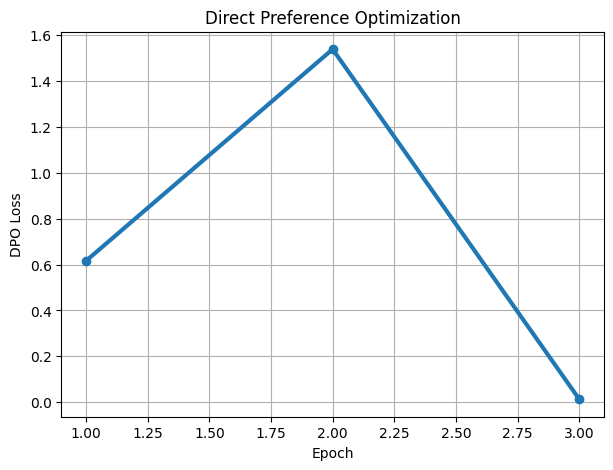

In [18]:
# Training Curve

plt.figure(figsize=(7,5))

plt.plot(

    range(

        1,

        EPOCHS+1

    ),

    loss_history,

    marker="o",

    linewidth=3

)

plt.xlabel("Epoch")

plt.ylabel("DPO Loss")

plt.title("Direct Preference Optimization")

plt.grid(True)

plt.show()

In [19]:
# Training Summary

print("="*60)

print("DIRECT PREFERENCE OPTIMIZATION REPORT")

print("="*60)

print()

print("Policy Model        : GPT-2")

print("Reference Model     : GPT-2 (Frozen)")

print("Preference Samples  :", len(dataset))

print("Epochs              :", EPOCHS)

print("Final DPO Loss      :", round(loss_history[-1],4))

print()

print("Training Completed Successfully")

DIRECT PREFERENCE OPTIMIZATION REPORT

Policy Model        : GPT-2
Reference Model     : GPT-2 (Frozen)
Preference Samples  : 8
Epochs              : 3
Final DPO Loss      : 0.0132

Training Completed Successfully


In [20]:
# Preference Accuracy

policy_model.eval()

correct = 0

with torch.no_grad():

    for sample in dataset:

        chosen = tokenize_pair(
            sample["prompt"],
            sample["chosen"]
        )

        rejected = tokenize_pair(
            sample["prompt"],
            sample["rejected"]
        )

        chosen_score = sequence_log_probability(
            policy_model,
            chosen["input_ids"],
            chosen["attention_mask"]
        )

        rejected_score = sequence_log_probability(
            policy_model,
            rejected["input_ids"],
            rejected["attention_mask"]
        )

        if chosen_score > rejected_score:
            correct += 1

accuracy = correct / len(dataset)

print("="*60)
print("Preference Accuracy :", round(accuracy*100,2), "%")

Preference Accuracy : 100.0 %


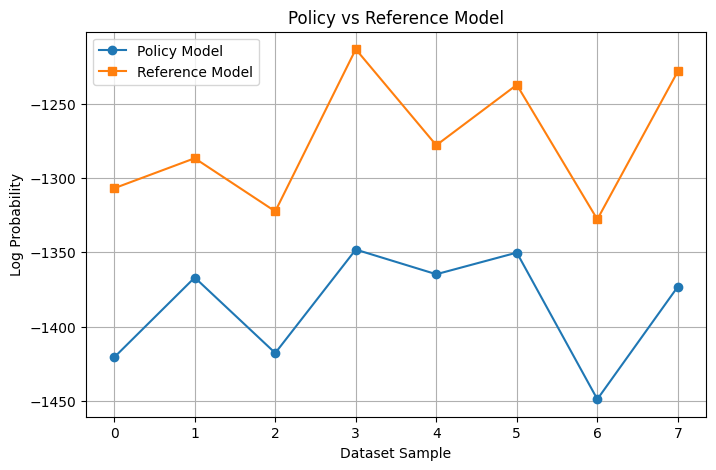

In [21]:
# Policy vs Reference Comparison

policy_scores = []
reference_scores = []

with torch.no_grad():

    for sample in dataset:

        chosen = tokenize_pair(
            sample["prompt"],
            sample["chosen"]
        )

        policy_score = sequence_log_probability(
            policy_model,
            chosen["input_ids"],
            chosen["attention_mask"]
        )

        reference_score = sequence_log_probability(
            reference_model,
            chosen["input_ids"],
            chosen["attention_mask"]
        )

        policy_scores.append(policy_score.item())
        reference_scores.append(reference_score.item())

plt.figure(figsize=(8,5))

plt.plot(
    policy_scores,
    marker="o",
    label="Policy Model"
)

plt.plot(
    reference_scores,
    marker="s",
    label="Reference Model"
)

plt.xlabel("Dataset Sample")
plt.ylabel("Log Probability")
plt.title("Policy vs Reference Model")
plt.legend()
plt.grid(True)

plt.show()

In [22]:
# Inference

prompt = "Explain Artificial Intelligence in simple words."

inputs = tokenizer(
    prompt,
    return_tensors="pt"
).to(device)

output = policy_model.generate(

    **inputs,

    max_new_tokens=50,

    do_sample=True,

    temperature=0.7,

    top_p=0.9

)

generated = tokenizer.decode(
    output[0],
    skip_special_tokens=True
)

print("="*60)
print("PROMPT")
print("="*60)
print(prompt)

print()

print("="*60)
print("MODEL RESPONSE")
print("="*60)
print(generated)

PROMPT
Explain Artificial Intelligence in simple words.

MODEL RESPONSE
Explain Artificial Intelligence in simple words.

The "human brain" is a highly complex and well understood computer program that was created to solve many complex problems. However, the most fundamental problem is how to learn it. The computer program is the best way to learn and understand the human
